# **1. Perkenalan Dataset**
Dataset yang digunakan adalah **Heart Attack Prediction Dataset**.
Target klasifikasi adalah kolom `class` yang bernilai `positive` atau `negative`.

---

### **Dokumentasi Dataset: Heart Disease Classification Dataset**

#### **1. Tautan Sumber Data (Data Source)**

Dataset ini diambil dari platform Kaggle yang diunggah oleh pengguna bernama **bharath011**:

* **URL Sumber:** [Kaggle - Heart Disease Classification Dataset](https://www.kaggle.com/datasets/bharath011/heart-disease-classification-dataset)

#### **2. Deskripsi Singkat & Konteks Data**

Penyakit Kardiovaskular (CVDs) merupakan salah satu penyebab kematian tertinggi di dunia. Menurut World Health Organization (WHO), diperkirakan 17,9 juta orang meninggal setiap tahunnya akibat penyakit ini, di mana serangan jantung dan stroke menjadi pemicu utamanya.

Dataset ini dibuat dengan tujuan untuk mengumpulkan karakteristik klinis, demografis, dan biokimia yang berkontribusi atau berkaitan erat dengan terjadinya serangan jantung. Melalui data ini, model Machine Learning dapat dikembangkan untuk melakukan klasifikasi dan deteksi dini guna membantu tenaga medis memprediksi risiko serangan jantung pada pasien secara lebih cepat.

#### **3. Dimensi dan Struktur Data**

* **Jumlah Sampel (Baris):** 1.319 baris data pasien.
* **Jumlah Fitur (Kolom):** 9 kolom, yang terdiri dari **8 fitur input (independen)** dan **1 fitur output/target (dependen)**.

#### **4. Detail Atribut / Variabel Data**

Berikut adalah rincian dari setiap kolom yang terdapat di dalam dataset:

| No | Nama Kolom / Fitur | Jenis Data | Deskripsi & Nilai Kunci |
| --- | --- | --- | --- |
| **1** | `Age` | Numerik | Usia pasien dalam satuan tahun. |
| **2** | `Gender` | Kategorikal / Biner | Jenis kelamin pasien (`0` = Perempuan, `1` = Laki-laki). |
| **3** | `Heart rate` (impulse) | Numerik | Denyut nadi atau detak jantung pasien per menit. |
| **4** | `Systolic BP` (pressurehight) | Numerik | Tekanan darah sistolik (batas atas saat jantung memompa). |
| **5** | `Diastolic BP` (pressurelow) | Numerik | Tekanan darah diastolik (batas bawah saat jantung beristirahat). |
| **6** | `Blood sugar` (glucose) | Numerik | Kadar gula atau glukosa di dalam darah pasien. |
| **7** | `CK-MB` (kcm) | Numerik | Kadar enzim *Creatine Kinase-Myocardial Band* (penanda adanya kerusakan pada otot jantung). |
| **8** | `Test-Troponin` (troponin) | Numerik | Kadar protein Troponin dalam darah (indikator sensitif untuk serangan jantung). |
| **9** | **`Class` (Target)** | Kategorikal / Biner | Indikator terjadinya serangan jantung (`0` = Tidak terkena serangan, `1` = Terkena serangan jantung). |

#### **5. Karakteristik Relevan untuk Analisis Proyek**

* **Kombinasi Fitur Klinis & Laboratorium:** Berbeda dengan UCI Heart Disease biasa yang berfokus pada hasil rekam medis (EKG) atau angiografi, dataset ini sangat menarik karena menyertakan **biomarker darah penting** seperti enzim **CK-MB** dan **Troponin**. Kedua zat ini secara medis dilepaskan ke dalam darah hanya ketika otot jantung mengalami cedera parah (seperti saat serangan jantung terjadi).
* **Tipe Prediksi:** Masalah yang diselesaikan menggunakan dataset ini adalah **Klasifikasi Biner (Binary Classification)**, yaitu menentukan apakah seorang pasien masuk ke dalam kategori berisiko tinggi/terkena serangan jantung (`1`) atau tidak (`0`).



# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv('../dataset/Heart Attack.csv')
display(df.head())

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


# **4. Exploratory Data Analysis (EDA)**

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB

Missing Values:
age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

Distribusi Target:
class
positive    810
negative    509
Name: count, dtype: int64


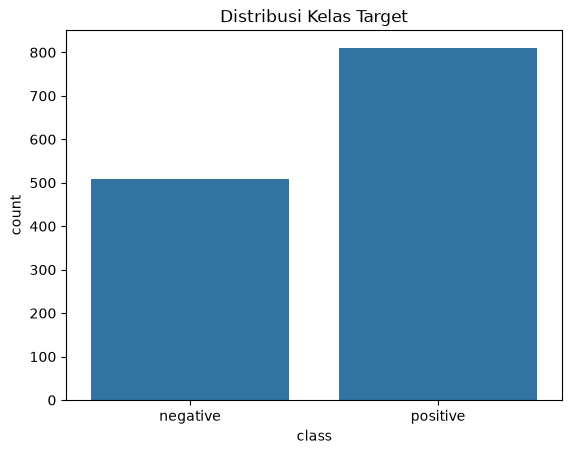

In [3]:
print("Info Dataset:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDistribusi Target:")
print(df['class'].value_counts())

sns.countplot(data=df, x='class')
plt.title('Distribusi Kelas Target')
plt.show()

# **5. Data Preprocessing**

In [4]:
# 1. Menghapus Data Kosong (Jika ada)
df.dropna(inplace=True)

# 2. Menghapus Data Duplikat
df.drop_duplicates(inplace=True)

# 3. Encoding Target
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# 4. Normalisasi/Standarisasi Fitur Numerik
scaler = StandardScaler()
numeric_cols = ['age', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

display(df.head())

# 5. Menyimpan data yang sudah dipreprocessing
df.to_csv('Heart_Attack_Clean.csv', index=False)
print("Data preprocessing selesai dan disimpan.")

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,0.572358,1,-0.239032,1.257215,0.764927,0.178459,-0.290962,-0.302342,0
1,-2.579640,1,0.303491,-1.117098,-1.872542,1.994344,-0.184072,0.605701,1
2,-0.087363,1,-0.277784,1.257215,0.337229,1.647189,-0.286859,-0.310140,0
3,0.572358,1,-0.161529,-0.274600,-1.230995,1.647189,-0.030324,-0.207032,1
4,-0.087363,1,-0.277784,-0.580963,-0.518166,2.047752,-0.306509,-0.310140,0


Data preprocessing selesai dan disimpan.
